# K-Means Clustering: Analyzing the Association between Percentage of Work-from-Home Workers and Median Housing Price pre- and post-pandemic

In this notebook we perform an analysis of how countys' work-from-home rate and median housing price vary over the years.

## Our analysis follows the following approach: 
> * Cluster counties based on their work-from-home rate across the years 2015 - 2024
> * Observe how each cluster's average work-from-home rate varies across the years 2015 - 2024 and list some examples of counties from each cluster
> * Observe the trajectory of average median-house-price (ZHVI) of each cluster over the years 2015 - 2024
> * Infer some common trends in the trajectories and look for trends in what type of clusters so an increase in median-house-price. <br>

## Our main findings in this notebook are:
> * Overall, all county groups demonstrate adoption patterns. All the counties have a higher percentage of work-from-home workers post-2020 than pre-2020.
> * The counties that had lower rates of work-from-home pre- and pos-pandemic show larger appreciations in housing prices.
> * Potentially, this indicates that remote workers from the expensive counties have moved to mid-tier counties where pricing was initially cheaper since work-from-home gave them the felxibility to move.
> * Housing demand was distriubted to mid-tier counties post pandemic which usually indicates the movement of people trigerring an increase in housing demand.
> * The corrrelation between work-from-rate and apprecitation in median-housing-price is weak which and correlation does not imply causation, so we cannot directly form a claim about the direct impact of work-from-home rates on housing prices.

## Why k-means?
> K-means clustering is an unsupervised machine learning algorithm that is able to cluster data points without the need for ground truth labels. The k-means clustering algorithm iteratively assigns data points to the nearest cluster and then updates the cluster centroids. The sum of squared distances of the data points to their cluster centroids is called inertia or within-cluster sum of squares (wcss). Essentially, the algorithm is minimizing this value. <br>
> In our analysis, we use k-means clustering to form groups of counties based on the percentage of work-from-home because we do not have pre-grouped counties. 

In [93]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Data Preprocessing and Cleaning 

> In this section we merge data across the different years in the scope of our analysis i.e., 2015 - 2024 with an exception of 2020. We drop the data that we clearly do not need in this analysis.

## Let's look at one year's dataframe

In [94]:
df = pd.read_csv('ACSDT1Y2015.B08301-Data.csv')
df.head()

,GEO_ID,NAME,B08301_001E,B08301_001M,B08301_002E,B08301_002M,B08301_003E,B08301_003M,B08301_004E,B08301_004M,...,B08301_017M,B08301_018E,B08301_018M,B08301_019E,B08301_019M,B08301_020E,B08301_020M,B08301_021E,B08301_021M,Unnamed: 44
0,Geography,Geographic Area Name,Estimate!!Total,Margin of Error!!Total,"Estimate!!Total!!Car, truck, or van","Margin of Error!!Total!!Car, truck, or van","Estimate!!Total!!Car, truck, or van!!Drove alone","Margin of Error!!Total!!Car, truck, or van!!Dr...","Estimate!!Total!!Car, truck, or van!!Carpooled","Margin of Error!!Total!!Car, truck, or van!!Ca...",...,Margin of Error!!Total!!Motorcycle,Estimate!!Total!!Bicycle,Margin of Error!!Total!!Bicycle,Estimate!!Total!!Walked,Margin of Error!!Total!!Walked,Estimate!!Total!!Other means,Margin of Error!!Total!!Other means,Estimate!!Total!!Worked at home,Margin of Error!!Total!!Worked at home,NaN
1,0500000US01003,"Baldwin County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0500000US01015,"Calhoun County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0500000US01043,"Cullman County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0500000US01049,"DeKalb County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [95]:
df.shape

(831, 45)

In [96]:
df.columns = df.loc[0].tolist()
df.drop(0, inplace = True)

In [97]:
df.head()

,Geography,Geographic Area Name,Estimate!!Total,Margin of Error!!Total,"Estimate!!Total!!Car, truck, or van","Margin of Error!!Total!!Car, truck, or van","Estimate!!Total!!Car, truck, or van!!Drove alone","Margin of Error!!Total!!Car, truck, or van!!Drove alone","Estimate!!Total!!Car, truck, or van!!Carpooled","Margin of Error!!Total!!Car, truck, or van!!Carpooled",...,Margin of Error!!Total!!Motorcycle,Estimate!!Total!!Bicycle,Margin of Error!!Total!!Bicycle,Estimate!!Total!!Walked,Margin of Error!!Total!!Walked,Estimate!!Total!!Other means,Margin of Error!!Total!!Other means,Estimate!!Total!!Worked at home,Margin of Error!!Total!!Worked at home,NaN
1,0500000US01003,"Baldwin County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0500000US01015,"Calhoun County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0500000US01043,"Cullman County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0500000US01049,"DeKalb County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0500000US01051,"Elmore County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [98]:
df.isna().sum()

Geography                                                                                                                       0
Geographic Area Name                                                                                                            0
Estimate!!Total                                                                                                               436
Margin of Error!!Total                                                                                                        436
Estimate!!Total!!Car, truck, or van                                                                                           436
Margin of Error!!Total!!Car, truck, or van                                                                                    436
Estimate!!Total!!Car, truck, or van!!Drove alone                                                                              436
Margin of Error!!Total!!Car, truck, or van!!Drove alone                                   

## Load the data from 2015 - 2024 as a big dataframe

> We take the data from the separate files of data across the years and append them to each other. This results in a column for the year that the data is from.  <br>  Also for k-means clustering, we don't need marginal error terms, so we remove them. Further, we do some cleaning on the column names to make the data cleaner and easier to handle. 

In [99]:
def stack_dataframes():
    dfs = [] 
    years = []
    folder_path = os.path.dirname(os.path.abspath("MATH189-FinalProject")) # Path to the repo folder where all the dataframes are. 

    for filename in sorted(os.listdir(folder_path)):

        if "B08301" not in filename or not filename.endswith(".csv"): 
            continue

        year = int(filename[7:11])
        years.append(year)

        df = pd.read_csv(filename)
        
        df.columns = df.loc[0].tolist()
        df.drop(0, inplace = True)
        df.drop(df.columns[-1], axis=1, inplace = True)
        df = df[[c for c in df.columns if not c.startswith('Margin')]] 
        # print(df.columns.tolist())
        df.columns = ['geo_id', 'name', 'total_workers', 'car_total', 'drove_alone', 'carpooled', 'carpool_2person', 'carpool_3person',
                      'carpool_4person', 'carpool_5or6person', 'carpool_7ormore', 'transit', 'bus', 'streetcar', 'subway', 'railroad', 
                      'ferryboat', 'taxicab', 'motorcycle', 'bicycle', 'walked', 'other', 'worked_at_home']

        df['year'] = year

        numeric_cols = df.columns.drop(['geo_id', 'name'])
        df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

        df['perc_wfh'] = df['worked_at_home'] / df['total_workers'] 

        dfs.append(df)

    stacked_df = pd.concat(dfs, ignore_index = True)
    return stacked_df     

In [100]:
df = stack_dataframes()
df

,geo_id,name,total_workers,car_total,drove_alone,carpooled,carpool_2person,carpool_3person,carpool_4person,carpool_5or6person,...,railroad,ferryboat,taxicab,motorcycle,bicycle,walked,other,worked_at_home,year,perc_wfh
0,0500000US01003,"Baldwin County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,NaN
1,0500000US01015,"Calhoun County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,NaN
2,0500000US01043,"Cullman County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,NaN
3,0500000US01049,"DeKalb County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,NaN
4,0500000US01051,"Elmore County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7575,0500000US72113,"Ponce Municipio, Puerto Rico",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024,NaN
7576,0500000US72127,"San Juan Municipio, Puerto Rico",136157.0,113143.0,103308.0,9835.0,8144.0,1199.0,258.0,39.0,...,1159.0,0.0,652.0,56.0,91.0,5454.0,3025.0,8700.0,2024,0.063897
7577,0500000US72135,"Toa Alta Municipio, Puerto Rico",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024,NaN
7578,0500000US72137,"Toa Baja Municipio, Puerto Rico",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024,NaN


In [101]:
df['year'].value_counts()

year
2024    861
2023    854
2022    848
2021    841
2019    840
2018    838
2017    837
2016    831
2015    830
Name: count, dtype: int64

In [102]:
df.isna().sum()

geo_id                   0
name                     0
total_workers         4275
car_total             4275
drove_alone           4275
carpooled             4275
carpool_2person       4275
carpool_3person       4275
carpool_4person       4275
carpool_5or6person    4275
carpool_7ormore       4275
transit               4275
bus                   4275
streetcar             4275
subway                4275
railroad              4275
ferryboat             4275
taxicab               4275
motorcycle            4275
bicycle               4275
walked                4275
other                 4275
worked_at_home        4275
year                     0
perc_wfh              4275
dtype: int64

## Investigate and Handle NaNs 

> We see that there is a large amount of NaNs in our data overall. K-means cannot handle NaNs so we will have to remove the NaN values. However, before we do that we can look at how the NaNs are distributed in the dataframe.

In [103]:
print(df[df['total_workers'].isna()].groupby('year').size())

year
2015    436
2016    438
2017    447
2018    461
2019    472
2021    563
2022    499
2023    489
2024    470
dtype: int64


In [104]:
df['perc_wfh'].isna().sum()

4275

> The NaNs are pretty equally distributed across the years in our dataframe. Now we will drop them as we progress in the k-means. Especially the rows where perc_wfh is missing i.e. either total_workers or worked_from_home are missing must be removed. 

## K-Means Part 1: Clustering counties based on rate of work from home across the years. 

The simplest K-means clustering we can perform is by clustering the counties by the trajectory of work from home rate across the years. 

### Step 1
Create pivot table of years and counties by their percentage of work from home. 

In [105]:
df_pivot = df.pivot_table(index='geo_id', columns='year', values='perc_wfh')
df_pivot.dropna(inplace = True)
df_pivot.shape

(221, 9)

In [106]:
df_pivot.isna().sum()

year
2015    0
2016    0
2017    0
2018    0
2019    0
2021    0
2022    0
2023    0
2024    0
dtype: int64

In [107]:
names = df[['geo_id', 'name']].drop_duplicates().set_index('geo_id')
df_pivot = df_pivot.join(names)
df_pivot

,2015,2016,2017,2018,2019,2021,2022,2023,2024,name
geo_id,,,,,,,,,,
0500000US01073,0.028849,0.026184,0.037150,0.042324,0.037037,0.133289,0.108476,0.104361,0.099859,"Jefferson County, Alabama"
0500000US02020,0.036638,0.043770,0.035985,0.043789,0.034843,0.126007,0.118640,0.090123,0.089712,"Anchorage Municipality, Alaska"
0500000US04013,0.059729,0.068409,0.068259,0.074120,0.079432,0.237837,0.221976,0.195987,0.177957,"Maricopa County, Arizona"
0500000US04019,0.045030,0.054269,0.052600,0.055224,0.068745,0.179036,0.146278,0.138848,0.137056,"Pima County, Arizona"
0500000US04021,0.054903,0.058966,0.057400,0.066643,0.074097,0.184084,0.163512,0.168706,0.175997,"Pinal County, Arizona"
...,...,...,...,...,...,...,...,...,...,...
0500000US53067,0.048474,0.062638,0.049684,0.063973,0.064575,0.233534,0.202172,0.190504,0.214320,"Thurston County, Washington"
0500000US55009,0.033028,0.047001,0.048959,0.039745,0.048228,0.148504,0.120109,0.119985,0.129392,"Brown County, Wisconsin"
0500000US55025,0.044731,0.049175,0.050629,0.044481,0.058196,0.243832,0.203682,0.180363,0.164304,"Dane County, Wisconsin"


In [108]:
df_pivot.dtypes

2015    float64
2016    float64
2017    float64
2018    float64
2019    float64
2021    float64
2022    float64
2023    float64
2024    float64
name     object
dtype: object

### Step 2 
Standardize the numeric variables. K-means clustering is affected by variables of different variation / standard deviation. Inorder to ensure that higher variability features are not disproportionately affecting the clustering, we perform standardization. <br> 
> This blog post: https://dmitrijskass.netlify.app/2019/10/22/effect-of-not-standardizing-variables-in-k-means-clustering/ was helpful in understanding the need to standardize data. 

In [109]:
sc = StandardScaler()
X = sc.fit_transform(df_pivot.drop(columns = ['name']))
X.shape

(221, 9)

### Step 3: Estimate a Good Number of Clusters
We use the elbow curve to determine the optimal number of clusters that the algorithm should create. <br>
The Intertia or Within-Cluster Sum of Squares is being optimized in the k-means algorithm. We can plot the inertia / WCSS for different number of clusters and we can find the "elbow" point. <br> The elbow point signifies the number of clusters after which performance / fit does not increase much i.e., performance / fit plateaus. This is a standard approach. <br> 
> See this article for a more detailed explanation: https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/ 

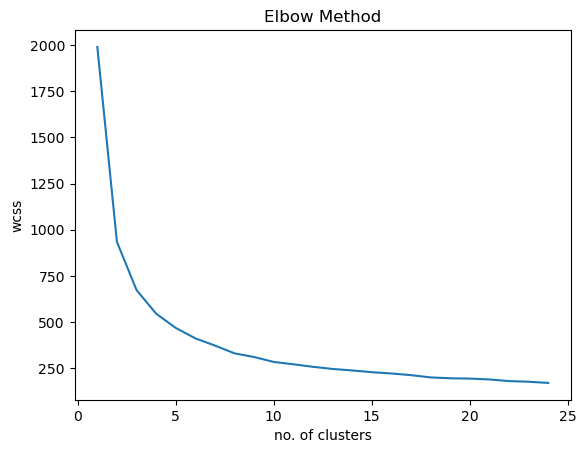

In [110]:
wcss = []
for i in range(1, 25):
    kmeans = KMeans(n_clusters = i, random_state = 42, n_init = 10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 25), wcss)
plt.title('Elbow Method')
plt.xlabel('no. of clusters')
plt.ylabel('wcss')
plt.show()

The elbow method is sometimes a little ambigious as is in our case. In such cases there is a fallback approach of using the silhouette score to find a good estimate for the number of clusters. The silhouette score takes the average of the distance of a datum from its cluster's other points and the distance of the datum from points in the neighboring cluster. A value close to 1 says that the cluster is well formed and separated whereas a value near -1 means that the clusters are not well separated. <br> 
> See this link for a better explanation: https://www.geeksforgeeks.org/machine-learning/what-is-silhouette-score/ 

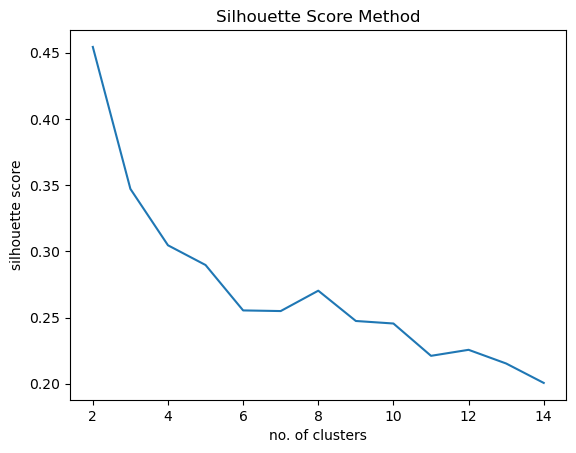

In [111]:
scores = []
for i in range(2, 15):
    km = KMeans(n_clusters = i, random_state = 42, n_init = 10, init = 'k-means++')
    labels = km.fit_predict(X)
    scores.append(silhouette_score(X, labels))
plt.figure()
plt.plot(list(range(2, 15)), scores)
plt.title('Silhouette Score Method')
plt.xlabel('no. of clusters')
plt.ylabel('silhouette score')
plt.show()

> According to the silhouette score, 2 clusters seems to be a good choice. However, since the silhouette score is just a guideline, 4 might be a better choice for our particular research question since 2 clusters is a major over-simplification. <br>
> Moreover, 4 clusters is a reasonable guess even by the elbow plot.

### Step 4
We run k-means with 4 clusters. 

In [112]:
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10)
df_pivot['cluster'] = km.fit_predict(X)

### Step 5
We visualize the rend in work from home percentage for each cluster. We average the percentage of work from home for each county in a given cluster over the years and plot it. 

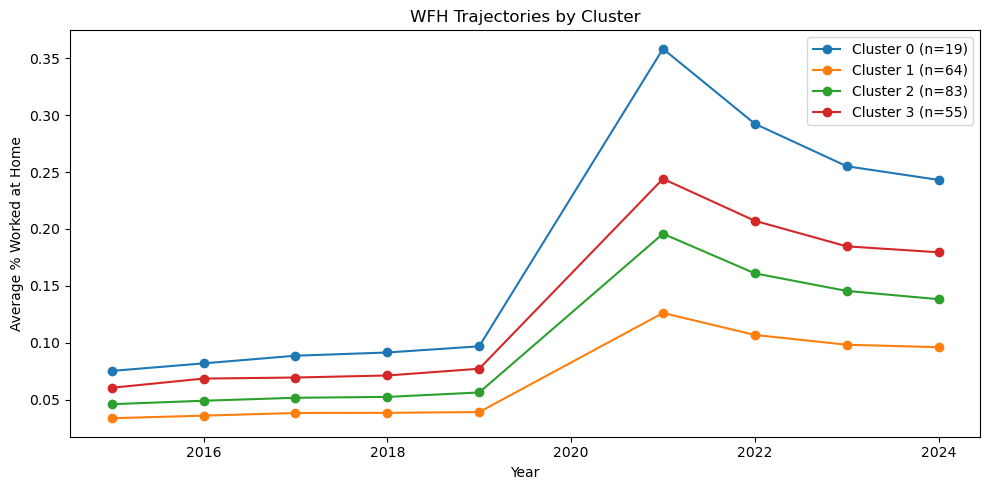

In [113]:
fig, ax = plt.subplots(figsize=(10, 5))

for cluster_id in range(k):
    # get all counties in this cluster
    mask = df_pivot['cluster'] == cluster_id
    year_cols = [2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024] 
    # compute the mean WFH trajectory across all counties in the cluster
    mean_trajectory = df_pivot.loc[mask, year_cols].mean()
    ax.plot(year_cols, mean_trajectory, marker='o', label=f'Cluster {cluster_id} (n={mask.sum()})')

ax.set_xlabel('Year')
ax.set_ylabel('Average % Worked at Home')
ax.set_title('WFH Trajectories by Cluster')
ax.legend()
plt.tight_layout()
plt.show()

> * Overall, all four clusters of counties demonstrate adoption patterns. All the counties have a higher percentage of work-from-home workers post-2020 than pre-2020.
> * Among the clusters, cluster 0 seems to represent counties that already had the highest rates of work-from-home workers, and this cluster shows the greatest spike in percentage of work-from-home workers post-pandemic. This cluster included counties such as San Francisco County, California, Boulder County, Colorado and Denver County, Colorado (see section below).

### Step 6
See some examples of counties in each cluster

In [114]:
for cluster_id in range(k):
    print(f"Cluster {cluster_id}")
    sample = df_pivot[df_pivot['cluster'] == cluster_id]['name'].head(10).tolist()
    print(sample)

Cluster 0
['Marin County, California', 'Placer County, California', 'San Francisco County, California', 'Boulder County, Colorado', 'Denver County, Colorado', 'Jefferson County, Colorado', 'District of Columbia, District of Columbia', 'Cobb County, Georgia', 'Fulton County, Georgia', 'Mecklenburg County, North Carolina']
Cluster 1
['Jefferson County, Alabama', 'Anchorage Municipality, Alaska', 'Pulaski County, Arkansas', 'Fresno County, California', 'Kern County, California', 'Monterey County, California', 'San Joaquin County, California', 'Solano County, California', 'Stanislaus County, California', 'Tulare County, California']
Cluster 2
['Pima County, Arizona', 'Los Angeles County, California', 'Riverside County, California', 'San Bernardino County, California', 'Santa Barbara County, California', 'Santa Clara County, California', 'Ventura County, California', 'Adams County, Colorado', 'Weld County, Colorado', 'New Castle County, Delaware']
Cluster 3
['Maricopa County, Arizona', 'Pin

## K-Means Part 2: Observing trjectory of median housing price for each county across the years. 

Now, we introduce the housing data from Zillow for the counties. Using this, we can now cluster based on housing prices and overlay the clusters from the previous section to see how the trends match each other. 

### Step 1
Merge in the Zillow data. This step requires some celaning of the FIPS code to match the geo-id from the previous dataset. <br>
We cite the use of AI for this particular section's FIPS merging section. 

In [115]:
zillow = pd.read_csv('data/County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv')

# Zillow splits the FIPS into two columns, combine them into a 5-digit string
zillow['fips'] = zillow['StateCodeFIPS'].astype(str).str.zfill(2) + zillow['MunicipalCodeFIPS'].astype(str).str.zfill(3)

# Zillow data is monthly — average all months within each year to get one value per year
# First grab only the date columns
date_cols = [c for c in zillow.columns if c.startswith('20')]

# For each year 2015-2024 (excluding 2020), average the monthly columns belonging to that year
for year in [2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024] :
    year_monthly_cols = [c for c in date_cols if c.startswith(str(year))]
    zillow[f'zhvi_{year}'] = zillow[year_monthly_cols].mean(axis=1)

# Keep only what we need
zhvi_cols = [f'zhvi_{y}' for y in [2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024] ]
zillow_clean = zillow[['fips'] + zhvi_cols]

df_pivot = df_pivot.reset_index()

# Extract the last 5 characters of geo_id to get the FIPS code
# e.g. '0500000US06037' → '06037'
df_pivot['fips'] = df_pivot['geo_id'].astype(str).str[-5:]

merged = pd.DataFrame(df_pivot.merge(zillow_clean, on='fips', how='inner'))

print('Counties after merge:', len(merged))
print(merged.head())

Counties after merge: 220
           geo_id      2015      2016      2017      2018      2019      2021  \
0  0500000US01073  0.028849  0.026184  0.037150  0.042324  0.037037  0.133289   
1  0500000US02020  0.036638  0.043770  0.035985  0.043789  0.034843  0.126007   
2  0500000US04013  0.059729  0.068409  0.068259  0.074120  0.079432  0.237837   
3  0500000US04019  0.045030  0.054269  0.052600  0.055224  0.068745  0.179036   
4  0500000US04021  0.054903  0.058966  0.057400  0.066643  0.074097  0.184084   

       2022      2023      2024  ...   fips      zhvi_2015      zhvi_2016  \
0  0.108476  0.104361  0.099859  ...  01073  123677.326674  129534.780300   
1  0.118640  0.090123  0.089712  ...  02020  315821.013906  322866.727471   
2  0.221976  0.195987  0.177957  ...  04013  224526.877135  244470.910374   
3  0.146278  0.138848  0.137056  ...  04019  177712.013805  185066.033763   
4  0.163512  0.168706  0.175997  ...  04021  166294.227767  180390.245410   

       zhvi_2017      zh

In [116]:
merged.columns

Index([   'geo_id',        2015,        2016,        2017,        2018,
              2019,        2021,        2022,        2023,        2024,
            'name',   'cluster',      'fips', 'zhvi_2015', 'zhvi_2016',
       'zhvi_2017', 'zhvi_2018', 'zhvi_2019', 'zhvi_2021', 'zhvi_2022',
       'zhvi_2023', 'zhvi_2024'],
      dtype='object')

### Step 2
We compute the percentage increase in ZHVI from 2019 to 2024 for the counties. <br>
Then for each cluster, we average the change in ZHVI. By sorting this in descending order, we can see how each of the cluster's median house index changed on average from 2015 to 2024. 

In [117]:
merged['zhvi_change'] = (merged['zhvi_2024'] - merged['zhvi_2015']) / merged['zhvi_2015']
print(merged.groupby('cluster')['zhvi_change'].mean().sort_values(ascending = False))

cluster
3    0.876081
2    0.867304
1    0.812967
0    0.731061
Name: zhvi_change, dtype: float64


### Step 3 
For each cluster, see the percentage increase in ZHVI from 2019 to 2024. We are checking for which clusters have the highest appreciation in ZHVI. 

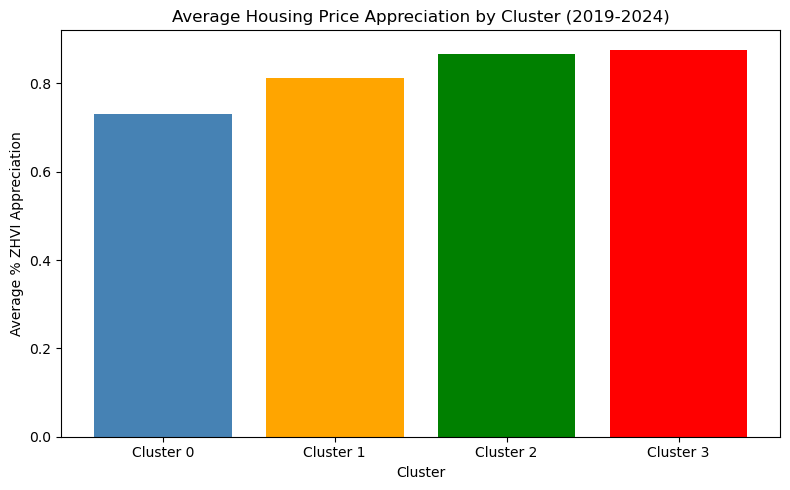

In [118]:
cluster_appreciation = merged.groupby('cluster')['zhvi_change'].mean()

plt.figure(figsize=(8, 5))
plt.bar(cluster_appreciation.index, cluster_appreciation.values, color=['steelblue', 'orange', 'green', 'red'])
plt.title('Average Housing Price Appreciation by Cluster (2019-2024)')
plt.xlabel('Cluster')
plt.ylabel('Average % ZHVI Appreciation')
plt.xticks(range(4), ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
plt.tight_layout()
plt.show()

> * Cluster 0 which is the most expensive group of counties, and also had the highest spike of work-from-home rates shows the lowest appreciation in housing price. Whereas, the counties that had lower rates of work-from-home pre- and post-pandemic show larger appreciations in housing prices.
> * This shows that potentially remote workers from the expensive cluster counties have moved to mid-tier counties where pricing was initially cheaper. 
> * It seems that the housing demand was distributed to suburban and mid-tier counties post pandemic which usually indicates the movement of people trigerring an increase in housing demand. 

### Step 4
We visualize the trajectory of ZHVI for each of our clusters across the years.

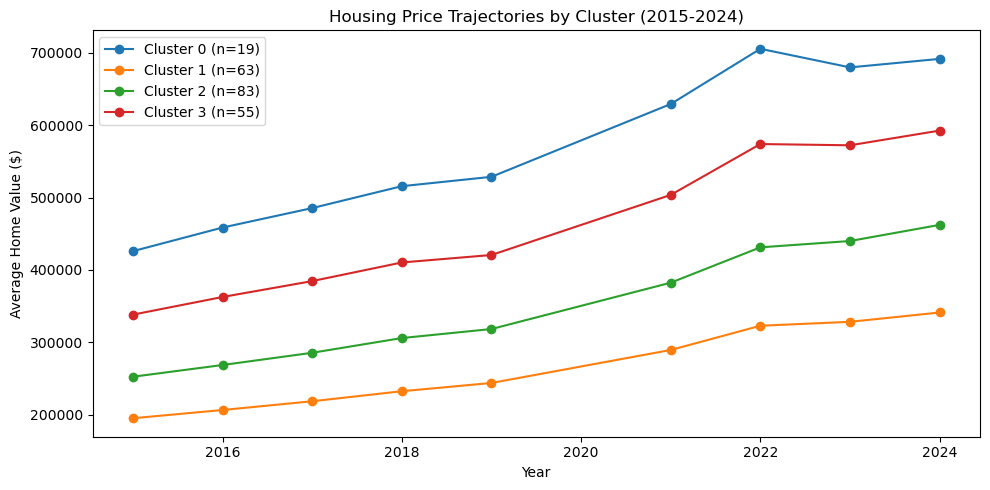

In [119]:
zhvi_cols = [f'zhvi_{y}' for y in [2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024]]
years = [2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024]

fig,  ax = plt.subplots(figsize=(10, 5))

for cluster_id in range(4):
    mask = merged['cluster'] == cluster_id
    mean_trajectory = merged.loc[mask, zhvi_cols].mean()
    ax.plot(years, mean_trajectory, marker='o', label=f'Cluster {cluster_id} (n={mask.sum()})')

ax.set_xlabel('Year')
ax.set_ylabel('Average Home Value ($)')
ax.set_title('Housing Price Trajectories by Cluster (2015-2024)')
ax.legend()
plt.tight_layout()
plt.show()

> * Cluster 0 had the highest absolute house prices but for our particular ananlysis the appreciation post-2020 is most relevant.
> * We see that all clusters have a steep increase in median-house-price post-2020. This indicates that housing became more expensive overall post-pandemic.
> * Tying back to our previous observation, the trajectory of median housing prices indicate the distribution of housing demand to suburban and mid-tier counties post-pandemic. 
> * We can relate this to other claims that housing dynamics changed post-pandemic due to hgiher interest-rates and supply constraints that the pandemic created.

### Step 5
For extra clarity, we fit a trend line to the scatter of appreciation in ZHVI against percentage increase in work from home rates. 

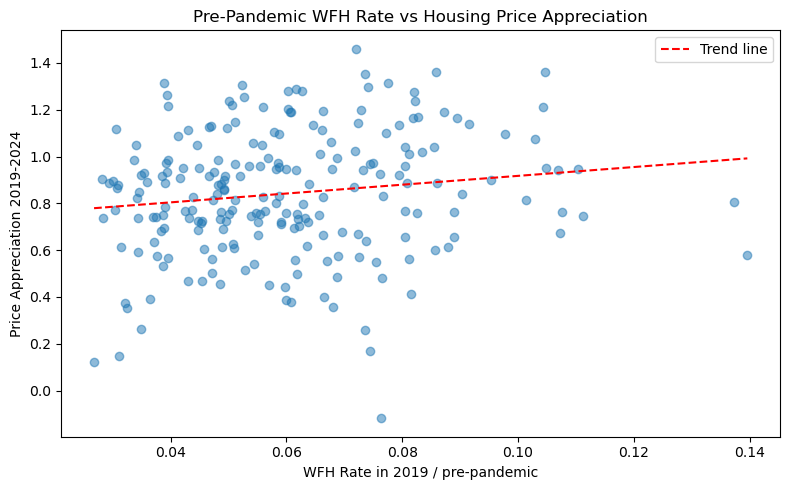

Correlation between 2019 WFH rate and price appreciation: 0.1461330630356129


In [120]:
plt.figure(figsize=(8, 5))
plt.scatter(merged[2019], merged['zhvi_change'], alpha=0.5)
plt.xlabel('WFH Rate in 2019 / pre-pandemic')
plt.ylabel('Price Appreciation 2019-2024') 
plt.title('Pre-Pandemic WFH Rate vs Housing Price Appreciation')

z = np.polyfit(merged[2019], merged['zhvi_change'], 1)
p = np.poly1d(z)
x_line = np.linspace(merged[2019].min(), merged[2019].max(), 100)
plt.plot(x_line, p(x_line), color='red', linestyle='--', label='Trend line')
plt.legend()
plt.tight_layout()
plt.show()

corr = merged[2019].corr(merged['zhvi_change'])
print(f'Correlation between 2019 WFH rate and price appreciation: {corr}')

> * The correlation between work-from-rate and appreciation in median-housing-price is ~ 0.146 which indicates a weak positive relationship. However, since correlation does not imply causation, we cannot directly form a claim from this alone.
> * There are probably other confounds that we currently do not have the data to check. For example, maybe high work-from-home rates correlate to wealthier and denser counties.

## Limitations

Now, we will run k-means clustering based on the percentage of work_from_home as well as as the ZHVI. This will give us clusters that are similar in terms of both these factors across the years. 

This pipeline is exactly the same as in the previous section. 

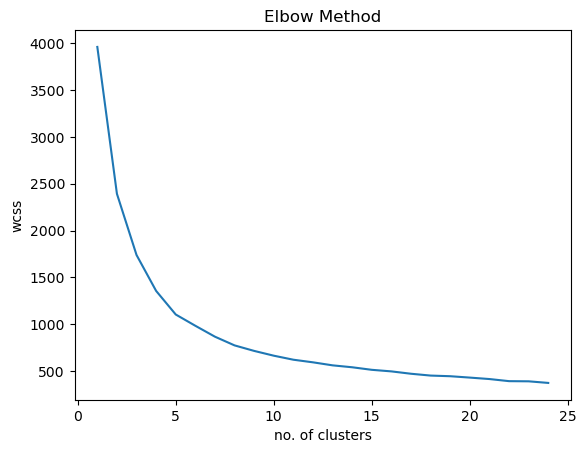

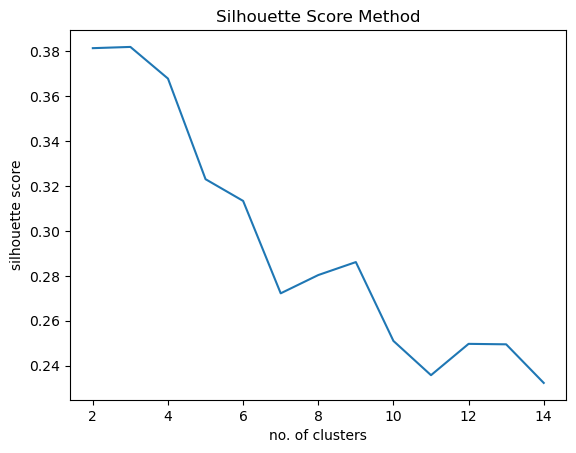

In [121]:
# Cluster on WFH + housing price trajectories combined
merged.columns = merged.columns.astype(str)

wfh_year_cols = ['2015', '2016', '2017', '2018', '2019', '2021', '2022', '2023', '2024']
zhvi_year_cols = ['zhvi_2015', 'zhvi_2016', 'zhvi_2017', 'zhvi_2018', 'zhvi_2019', 'zhvi_2021', 'zhvi_2022', 'zhvi_2023', 'zhvi_2024']

X = merged[zhvi_year_cols + wfh_year_cols]

sc = StandardScaler()
X = sc.fit_transform(X)

# Find optimal k:
wcss = []
for i in range(1, 25):
    kmeans = KMeans(n_clusters = i, random_state = 42, n_init = 10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 25), wcss)
plt.title('Elbow Method')
plt.xlabel('no. of clusters')
plt.ylabel('wcss')
plt.show()

# Use silhouette score: 
scores = []
for i in range(2, 15):
    km = KMeans(n_clusters = i, random_state = 42, n_init = 10, init = 'k-means++')
    labels = km.fit_predict(X)
    scores.append(silhouette_score(X, labels))
plt.figure()
plt.plot(list(range(2, 15)), scores)
plt.title('Silhouette Score Method')
plt.xlabel('no. of clusters')
plt.ylabel('silhouette score')
plt.show()

Similar to the earlier scenario, both the elbow curve and the silhouette score are hard to interpret or are pointing at a very small number of clusters. For our research question, 4 clusters again seem for like a good choice. 

In [122]:
merged.columns.tolist()

['geo_id',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2021',
 '2022',
 '2023',
 '2024',
 'name',
 'cluster',
 'fips',
 'zhvi_2015',
 'zhvi_2016',
 'zhvi_2017',
 'zhvi_2018',
 'zhvi_2019',
 'zhvi_2021',
 'zhvi_2022',
 'zhvi_2023',
 'zhvi_2024',
 'zhvi_change']

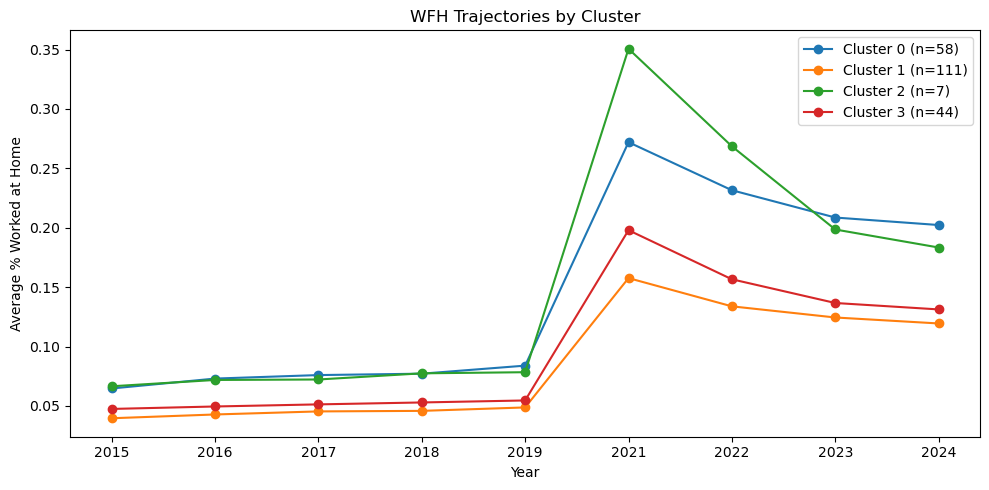

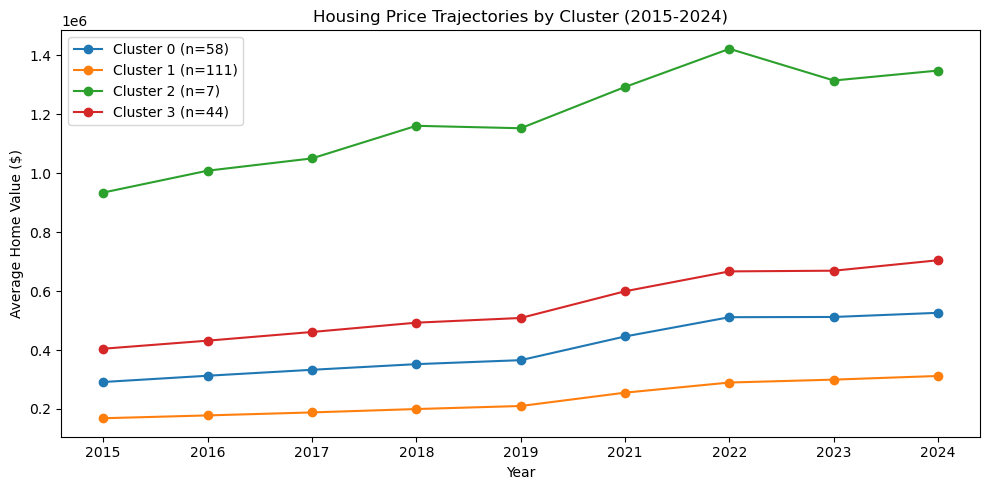

In [123]:
# Run K-means 
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10)
merged['predicted_cluster'] = km.fit_predict(X)

# Visualize 
fig, ax = plt.subplots(figsize=(10, 5))

for cluster_id in range(k):
    # get all counties in this cluster
    mask = merged['predicted_cluster'] == cluster_id
    year_cols = wfh_year_cols
    # compute the mean WFH trajectory across all counties in the cluster
    mean_trajectory = merged.loc[mask, year_cols].mean()
    ax.plot(wfh_year_cols, mean_trajectory, marker='o', label=f'Cluster {cluster_id} (n={mask.sum()})')

ax.set_xlabel('Year')
ax.set_ylabel('Average % Worked at Home')
ax.set_title('WFH Trajectories by Cluster')
ax.legend()
plt.tight_layout()
plt.show()

fig,  ax = plt.subplots(figsize=(10, 5))

for cluster_id in range(4):
    mask = merged['predicted_cluster'] == cluster_id
    mean_trajectory = merged.loc[mask, zhvi_year_cols].mean()
    ax.plot(wfh_year_cols, mean_trajectory, marker='o', label=f'Cluster {cluster_id} (n={mask.sum()})')

ax.set_xlabel('Year')
ax.set_ylabel('Average Home Value ($)')
ax.set_title('Housing Price Trajectories by Cluster (2015-2024)')
ax.legend()
plt.tight_layout()
plt.show()


> < INSERT OBSERVATION >

> * Our data does not cover all counties in the U.S. We only have data for counties that have a population of 65K and higher. So the smaller communities and most sub-urban areas are not present in our analysis.
> * Our data is missing for the year 2020 which was the most significant year of the pandemic. This is due to widespread disruptions caused by the pandemic.
> * Remote work rates and housing prices are both correlated with income levels, local industry composition, and pre-existing housing supply constraints. Our analysis does not control for these factors, so we cannot attribute housing price appreciation to remote work alone.
> * The Zillow Index we are using is just an estimate based on their model for property prices.
> * K-means is very sensitive to initialization. Different choices of k can lead to varying results. Also k-means is unstable for large datasets. 